# Module: Plotting

One of the main usecases of `SegTraQ` is to compare different segmentation methods. To facilitate this task, you can make use of the plotting module (`pl`).
In order to use it, you need to prepare your data in the form of a dictionary that maps the method name to the corresponding `SegTraQ` object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

## Data Preparation

First, we need to get the data into the right format. This closely follows the [Xenium Focus](10x_xenium_focus.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings(action="ignore")

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

In [2]:
# === READING SPATIALDATA OBJECTS ===
sdata_xenium_ws = sd.read_zarr("../../data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/proseg2.zarr")
sdata_segger_ws = sd.read_zarr("../../data/segger.zarr")

# === CROPPING ===
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h


def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)
sdata_segger = crop(sdata_segger_ws)

# === CREATING SEGTRAQ OBJECTS ===
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_segger = segtraq.SegTraQ(
    sdata_segger, images_key="image", tables_centroid_x_key="cell_centroid_x", tables_centroid_y_key="cell_centroid_y"
)

# === PUTTING EVERYTHING INTO A DICTIONARY ===
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg, "segger": st_segger}

no parent found for <ome_zarr.reader.Label object at 0x7f8589f027b0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a063ed0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f8589ecf250>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858aab6fd0>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a209f30>: None
no parent found for <ome_zarr.reader.Label object at 0x7f8589ecab10>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a8c3350>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a8c3460>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a8bfa50>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a8be350>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a942210>: None
no parent found for <ome_zarr.reader.Label object at 0x7f858a942120>: None


## Run desired metrics
Now, we can run all of the metrics we want on this dataset. For now, we simply run a label transfer and run some `scanpy` functions to compute the UMAP coordinates.

In [3]:
# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", inplace=True)

# Plots for individual samples

The `pl` module provides methods to plot different things: on one hand, it can be used to visualize certain characteristics of a sample, and on the other, it can be used to compare between different samples or segmentation methods. Let's start by looking at some sample-specific plots. Specifically, we can look at the distribution of transcripts and different segmentation features across the x and y coordinate. For some technologies (such as CosMx), this can help to detect stitching artefacts.

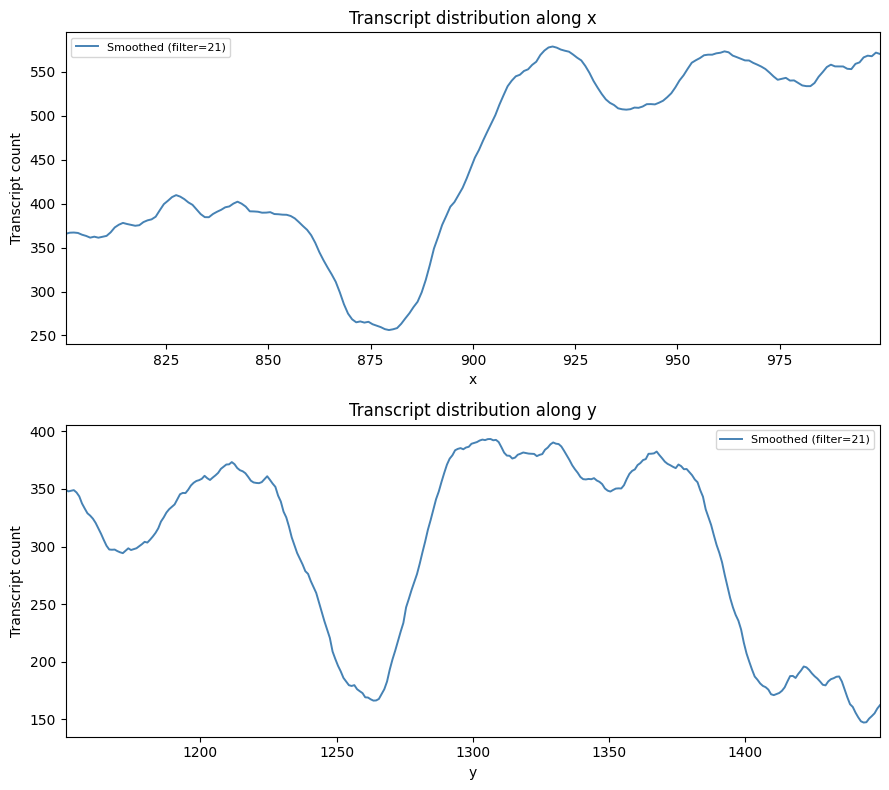

In [4]:
# transcript distribution across the x and y axis of the image
# the filter size (default: 21) can be used to get an idea for broader trends
_ = st_xenium.pl.transcript_distribution_across_space(filter_size=21)

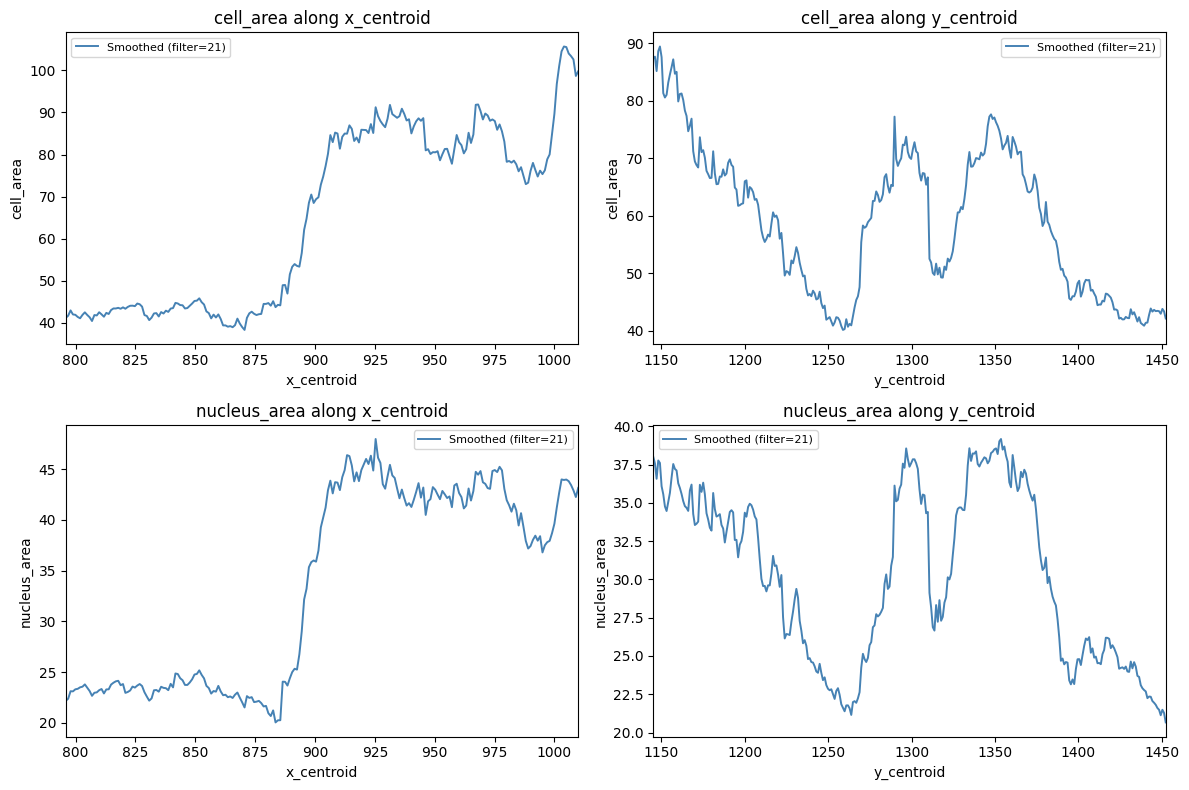

In [5]:
# features of the segmentation across the axes
_ = st_xenium.pl.feature_distribution_across_space(features=["cell_area", "nucleus_area"], filter_size=21)

We can see two things here: for the Xenium segmentation, the right part of the image contains more transcripts. Its cells are also larger. We can use `spatialdata_plot` to have a look at the actual data.

INFO     Value for parameter 'color' appears to be a color, using it as such.                                      


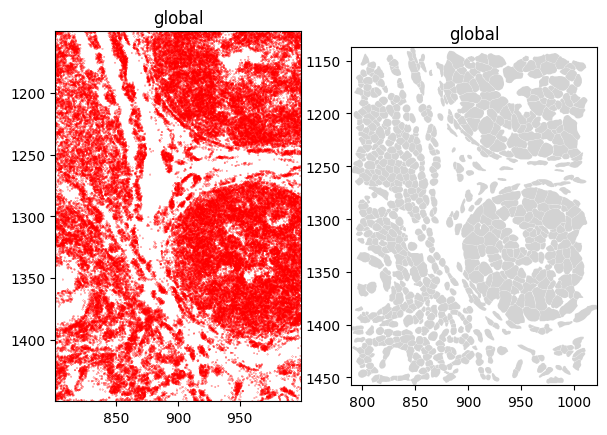

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(7, 7), dpi=100)
st_xenium.sdata.pl.render_points("transcripts", size=0.01, color="red", method="matplotlib").pl.show(ax=ax[0])
st_xenium.sdata.pl.render_shapes("cell_boundaries").pl.show(ax=ax[1])

Here, this is actually due to the structure of the tissue (large tumor cells are on the right side of the image). When applying these methods on larger tissues, they can also help to detect technical artefacts.

# Comparing between segmentation methods

We can also use the `pl` module to compare between different segmentation methods. All we need to do is pass our dictionary of `SegTraQ` objects.

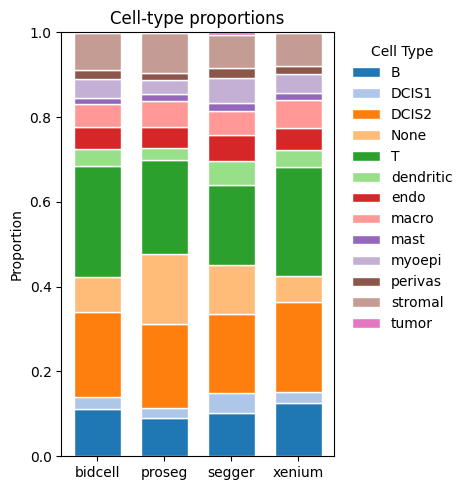

In [7]:
_ = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type")

Before we can plot the UMAP, we need to actually compute it.

In [8]:
for _, st in st_dict.items():
    # extracting the anndata object from the spatialdata object and performing appropriate normalization
    adata = st.sdata.tables["table"]
    adata.layers["raw"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

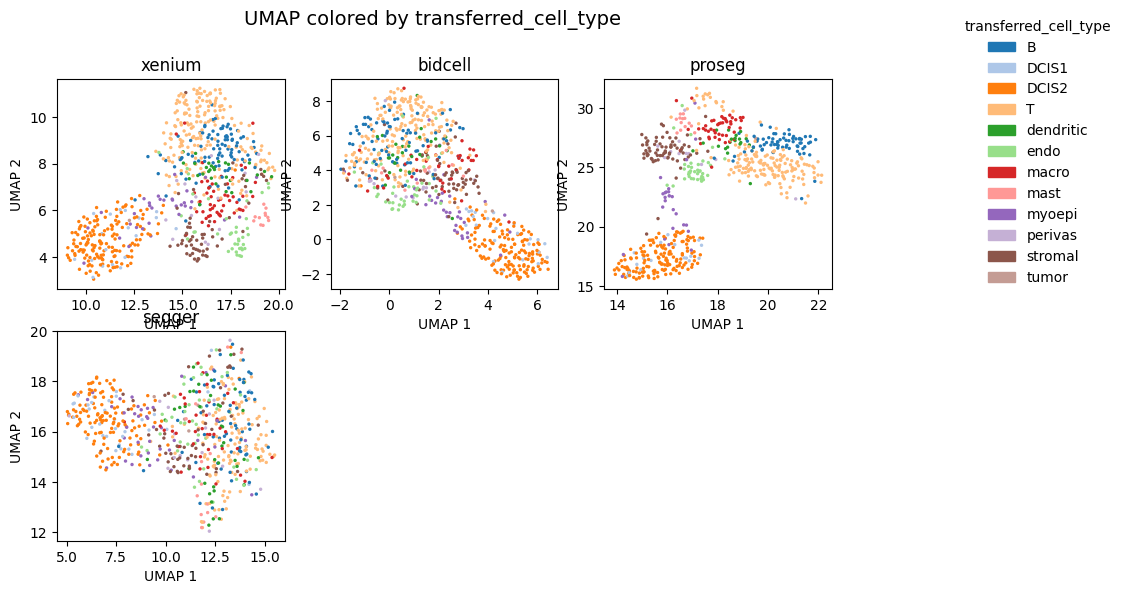

In [9]:
_ = segtraq.pl.umap(st_dict, color="transferred_cell_type", legend=True, figsize=(10, 6))

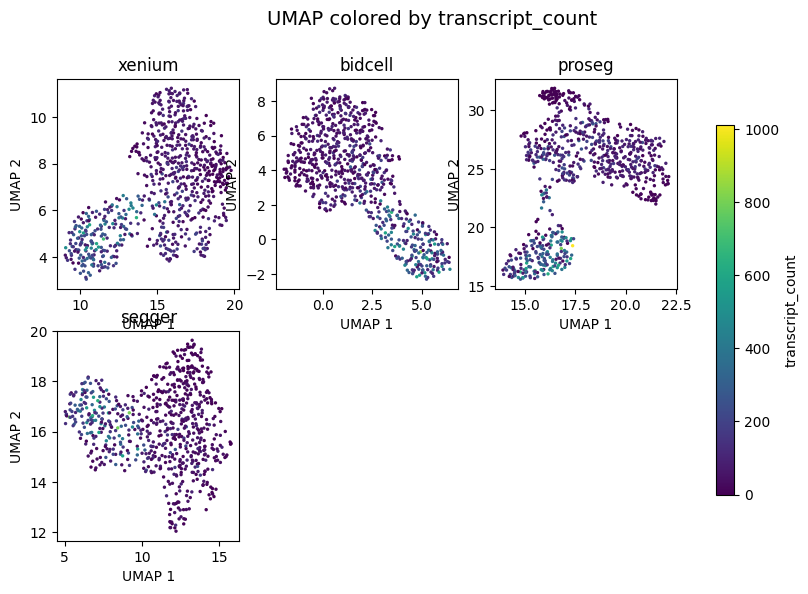

In [10]:
_ = segtraq.pl.umap(st_dict, color="transcript_count", legend=True, figsize=(10, 6))

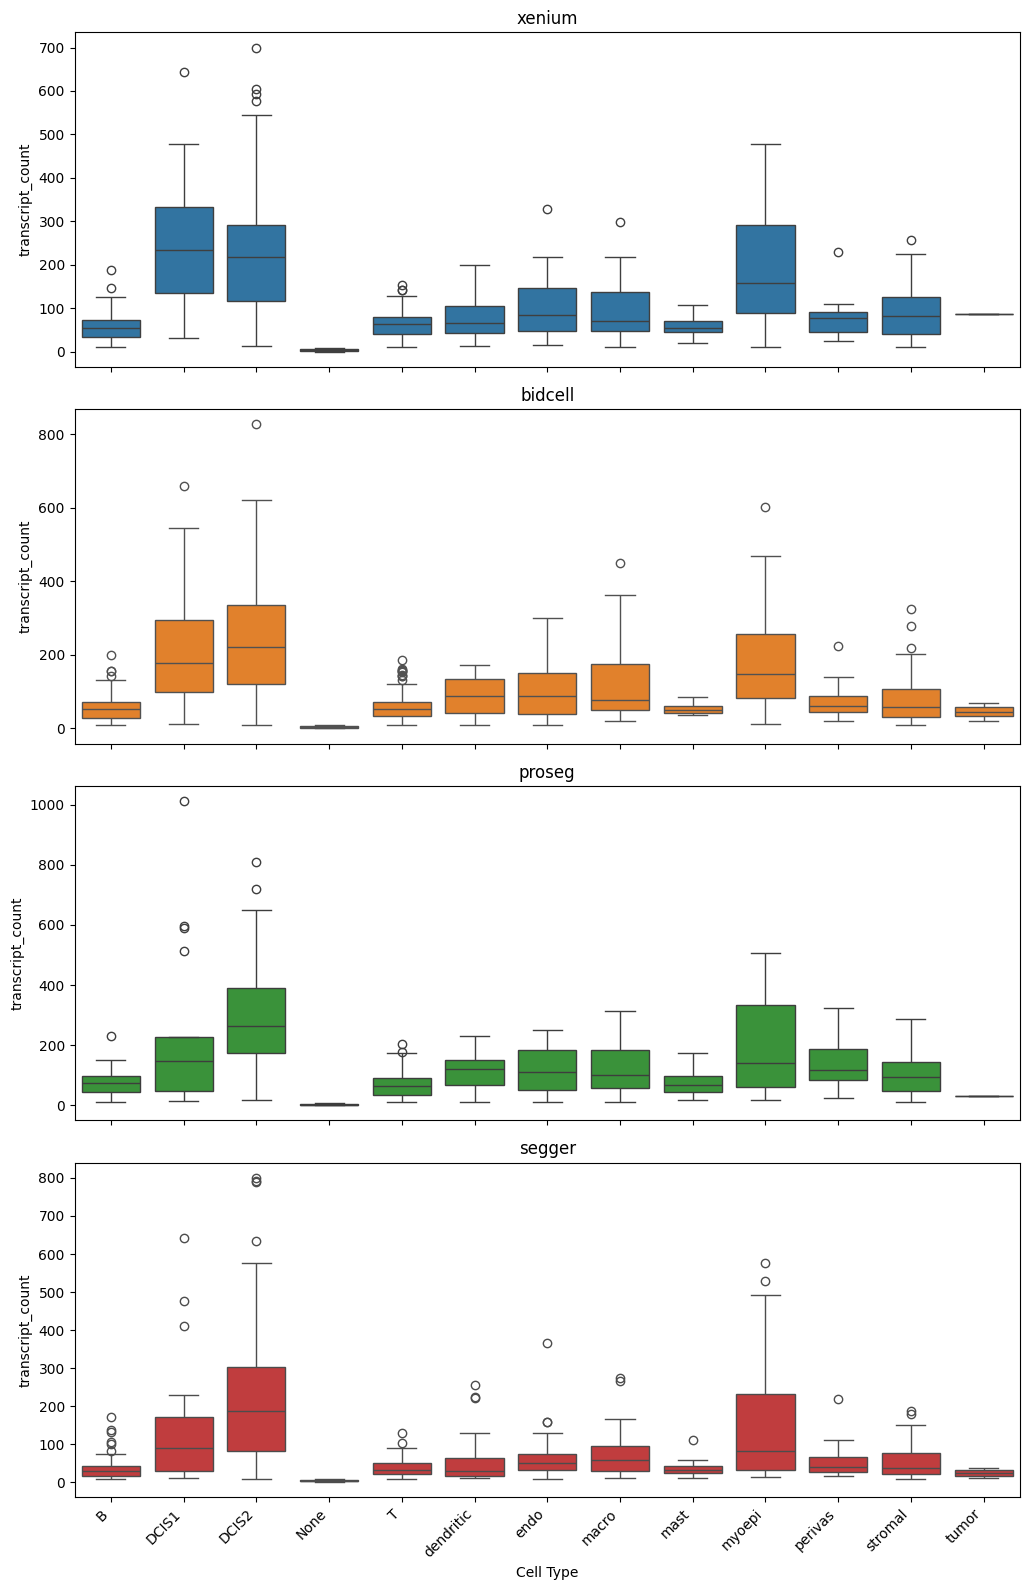

In [11]:
_ = segtraq.pl.boxplot(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

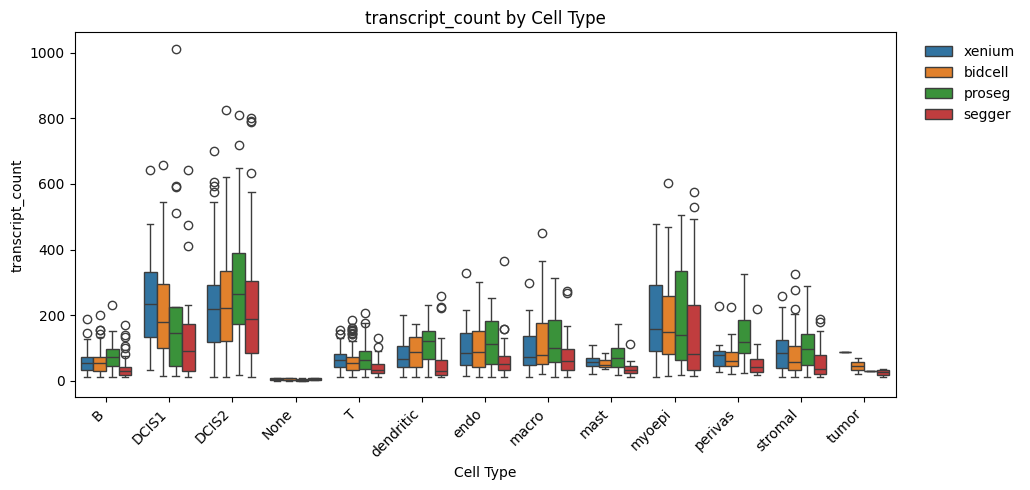

In [12]:
_ = segtraq.pl.boxplot_combined(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

## Session Info

In [13]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.7.2
0.2.13
